# STANDARD update — 2026-09-16T05:40:47+00:00

Block **64,265,663**, Robinhood chain **4663**. Compared with **2026-09-16T02:57:33+00:00**. [Full findings and interpretation](FINDINGS.md).

This is a fresh evidence update using the previous model. Scenario weights are not calibrated, and hypothetical returns are not executed trades. Locked liquidity remains in the future modeled curve.

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
from IPython.display import display,Image
ROOT=next(p for p in [Path.cwd(),*Path.cwd().parents] if (p/'behavior_model.py').exists()); PACKET=ROOT/'behavior-updates/2026-09-16T054047Z'; D=PACKET/'results'
s=json.loads((D/'update-summary.json').read_text())
display(pd.Series(s).to_frame('Fresh observation'))

,Fresh observation
snapshot_utc,2026-09-16T05:40:47+00:00
previous_snapshot_utc,2026-09-16T02:57:33+00:00
block,64265663
block_hash,0xe02747f5426047f715c7a4dc56ad72b9de3db6579d7a...
elapsed_hours,2.720556
price_ETH,0.000104
price_change_since_previous,0.091475
pool_principal_ETH,2393.59371
pool_principal_tokens,32086426.030059
buy_ETH,429.884575


## Final market check

This later check covers price, canonical flows and the buyback vault only. The full wallet/branch dataset and model remain pinned at 05:40:47 UTC.

In [2]:
tail=json.loads((PACKET/'tail-check.json').read_text())
display(pd.Series({'timestamp_utc':str(pd.Timestamp(int(tail['header']['timestamp'],16),unit='s',tz='UTC')),'price_ETH':tail['price_ETH'],'change_since_full_snapshot':tail['price_ETH']/s['price_ETH']-1,'buy_ETH_since_full_snapshot':tail['buy_ETH'],'sell_ETH_since_full_snapshot':tail['sell_ETH'],'lastTickAt':tail['lastTickAt']}).to_frame('Later market check'))

,Later market check
timestamp_utc,2026-09-16 05:56:10+00:00
price_ETH,0.000101
change_since_full_snapshot,-0.022989
buy_ETH_since_full_snapshot,1.2986
sell_ETH_since_full_snapshot,45.577401
lastTickAt,0


## 1. Check the earlier paths against what actually happened

The old paths were already saved before this observation. One comparison cannot calibrate probabilities; the cautious case missed the rebound and the bullish case overshot it.

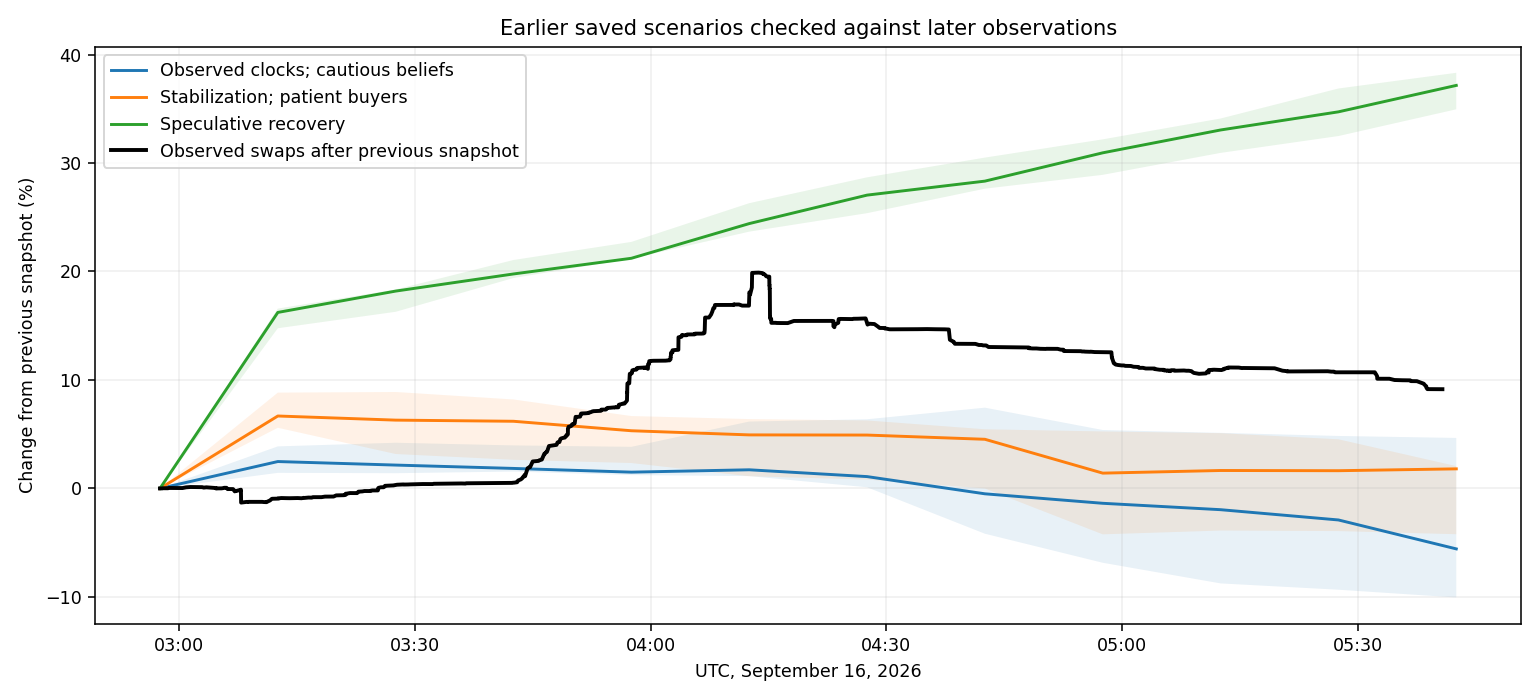

,old_path_min,old_path_median,old_path_max,actual
case,,,,
Observed clocks; cautious beliefs,-0.099691,-0.052598,0.046759,0.091475
Stabilization; patient buyers,-0.041873,0.019289,0.020592,0.091475
Speculative recovery,0.346621,0.368681,0.381469,0.091475
Replacement selling accelerates,-0.187960,-0.186203,-0.184787,0.091475
Owner executes buybacks,-0.075778,-0.024822,0.091026,0.091475
Crowded bank-exit expectations,-0.234170,-0.184028,-0.156165,0.091475
No branch expansion,-0.186414,-0.151683,-0.113269,0.091475
No new outside capital,-0.113795,0.017367,0.035873,0.091475


In [3]:
display(Image(filename=str(D/'previous-path-check.png')))
check=pd.read_csv(D/'previous-path-check.csv')
display(check.groupby('case',sort=False).agg(old_path_min=('previous_path_return_at_new_pin','min'),old_path_median=('previous_path_return_at_new_pin','median'),old_path_max=('previous_path_return_at_new_pin','max'),actual=('observed_return','first')))

## 2. Actual branch funding and remaining seller inventories

Funding is rebased to the previous 02:57:33 snapshot. Today is sold out. The next-day allocation is a feasible funding construction, not a prediction of auction participation.

In [4]:
funding=json.loads((D/'interval-funding/followup-summary.json').read_text())
display(pd.Series({k:v for k,v in funding.items() if k.startswith('license_paid_')}).to_frame('STANDARD'))
display(pd.read_csv(D/'next-day-license-feasibility.csv')[['ledger_used','wallet_used','new_tokens_needed']].sum().to_frame('Next-day feasible funding'))
display(pd.read_csv(D/'strategy-stocks.csv'))
display(pd.read_csv(D/'seller-inventory-and-entry.csv').query('previous_seller_group').head(15))
display(pd.read_csv(D/'flow-windows.csv').tail(6))

,STANDARD
license_paid_from_prior_bank_balance,191377.227179
license_paid_from_new_issuance,1187.697149
license_paid_from_prefunded_wallet_tokens,371854.819306
license_paid_from_new_canonical_tokens,107055.365860
license_paid_from_new_other_custody_tokens,11933.433938


,Next-day feasible funding
ledger_used,3.363300e+05
wallet_used,2.616484e+06
new_tokens_needed,0.000000e+00


,strategy,addresses,tokens,native_ETH,sold_tokens_6h
0,charter_owner,941,1.031979e+07,2547.669845,1.401790e+06
1,inactive_holder,15495,4.138955e+07,2774.080733,0.000000e+00
2,recent_buyer,294,7.858061e+06,711.044994,0.000000e+00
3,recent_seller,488,2.191547e+06,584.572335,8.880301e+06
4,two_way,94,1.883327e+06,184.075309,1.609995e+06


,address,strategy,wallet_tokens,sell_tokens_6h,charter_count,first_pool_buy_utc_approx,previous_seller_group,inventory_own_pool_buy,inventory_transferred_pool_buy,inventory_branch_withdrawal,inventory_transferred_branch_withdrawal,inventory_initial_allocation,inventory_transferred_allocation,inventory_other_custody_or_unresolved,inventory_own_other_pool_buy,inventory_transferred_other_pool_buy
24,0xa65ce1d604fa901c13aa29f2126a57d9032e412b,recent_seller,450000.000000,119999.850000,0,2026-09-15T06:02:49.675126791+00:00,True,450000.000000,0.000000,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000
30,0xd026f7a62fad79952d2f136ebd598a71b0053da1,recent_seller,367702.635322,79353.972096,0,2026-09-15T01:08:07.117894650+00:00,True,245348.954225,53879.532466,0.0,0.0,0.0,0.0,64827.407663,3646.740968,0.000000
50,0xfb0d8b94027c5109ae89c5f08b025cc598cf6f49,recent_buyer,259994.978798,0.000000,0,2026-09-15T01:00:42.105549574+00:00,True,259994.978798,0.000000,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000
85,0xaae01d26a2100224f724df95fafacd1d07c13593,inactive_holder,150000.000000,0.000000,0,NaN,True,0.000000,150000.000000,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000
132,0x681d22c5e615c7a876026ceba3dc36c6dde5b97d,two_way,100125.434984,91000.000000,0,2026-09-15T01:34:47+00:00,True,87580.765484,6307.696315,0.0,0.0,0.0,0.0,6236.973186,0.000000,0.000000
140,0xa91392aea58fc1543b0d9b314b0cfab7e1dc7da6,recent_buyer,94435.930456,0.000000,0,2026-09-15T01:25:05.846198559+00:00,True,56265.277016,3934.370400,0.0,0.0,0.0,0.0,28893.671070,5200.844364,141.767606
141,0xb9e98a981adc50aacc93625990b86a6524c3d3e7,recent_seller,92761.312943,103520.100141,0,2026-09-15T01:29:56.172510624+00:00,True,0.000000,0.000000,0.0,0.0,0.0,0.0,81228.120842,11533.192100,0.000000
143,0x669e5517086ffef7bdc404e42854922a12ee4910,inactive_holder,89897.248186,0.000000,0,2026-09-15T01:07:33.003039598+00:00,True,89897.248186,0.000000,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000
155,0xe8e4eb3fe4a93b45ddc4589abdd8f8e006d0533d,charter_owner,82306.889106,20666.172576,1,2026-09-15T01:03:30.501935482+00:00,True,82306.889106,0.000000,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000
177,0x5140087842da3cbc55ff69ba74b4239af219c4b6,charter_owner,70880.563683,46100.060477,1,2026-09-15T01:02:19.618709564+00:00,True,44314.448905,13904.538933,0.0,0.0,0.0,0.0,10770.030436,1891.545409,0.000000


,from_utc,to_utc,buy_ETH,sell_ETH,sold_tokens,new_seller_tokens,new_seller_addresses,new_buyer_ETH,new_buyer_addresses,owner_buy_ETH
12,2026-09-16T03:40:47+00:00,2026-09-16T04:00:47+00:00,197.240154,6.203749,61676.932317,57501.250183,9,33.406262,35,134.196438
13,2026-09-16T04:00:47+00:00,2026-09-16T04:20:47+00:00,144.522463,79.575920,719743.119533,100465.375452,13,47.486895,22,70.270900
14,2026-09-16T04:20:47+00:00,2026-09-16T04:40:47+00:00,11.536326,52.839948,489619.485402,87487.813372,22,2.641284,7,8.063592
15,2026-09-16T04:40:47+00:00,2026-09-16T05:00:47+00:00,0.641038,36.069929,341147.271160,131736.134082,43,0.234180,4,0.000000
16,2026-09-16T05:00:47+00:00,2026-09-16T05:20:47+00:00,15.254334,22.729052,217654.828834,138327.509525,32,5.687315,13,1.955100
17,2026-09-16T05:20:47+00:00,2026-09-16T05:40:47+00:00,0.361003,29.573469,285617.339563,143343.369252,10,0.165133,1,0.000000


## 3. Fresh-state scenarios

Same eight parameter sets, fresh on-chain inputs, four seeds each. These restart momentum and the reversion anchor at the new snapshot. The numbers are conditional experiments, not updated probabilities. All paths include elapsed hours/days and UTC timestamps.

,median_return,minimum,maximum,licenses,fresh_license_ETH,prefunding_ETH
case,,,,,,
Observed clocks; cautious beliefs,-0.127758,-0.270980,0.429194,100.0,7.802660,302.220119
Stabilization; patient buyers,0.003210,-0.012425,0.030414,100.0,41.570527,224.308288
Speculative recovery,0.998533,0.677204,1.127840,100.0,24.430686,290.786900
Replacement selling accelerates,-0.517636,-0.526298,-0.194867,13.0,8.539704,43.321995
Owner executes buybacks,-0.032748,-0.129113,0.175389,100.0,9.927521,312.062488
Crowded bank-exit expectations,-0.517023,-0.569212,-0.451072,3.5,4.003307,0.034961
No branch expansion,-0.009844,-0.333041,0.220929,0.0,0.000000,0.000000
No new outside capital,-0.190034,-0.316065,-0.120253,100.0,70.400151,245.533556


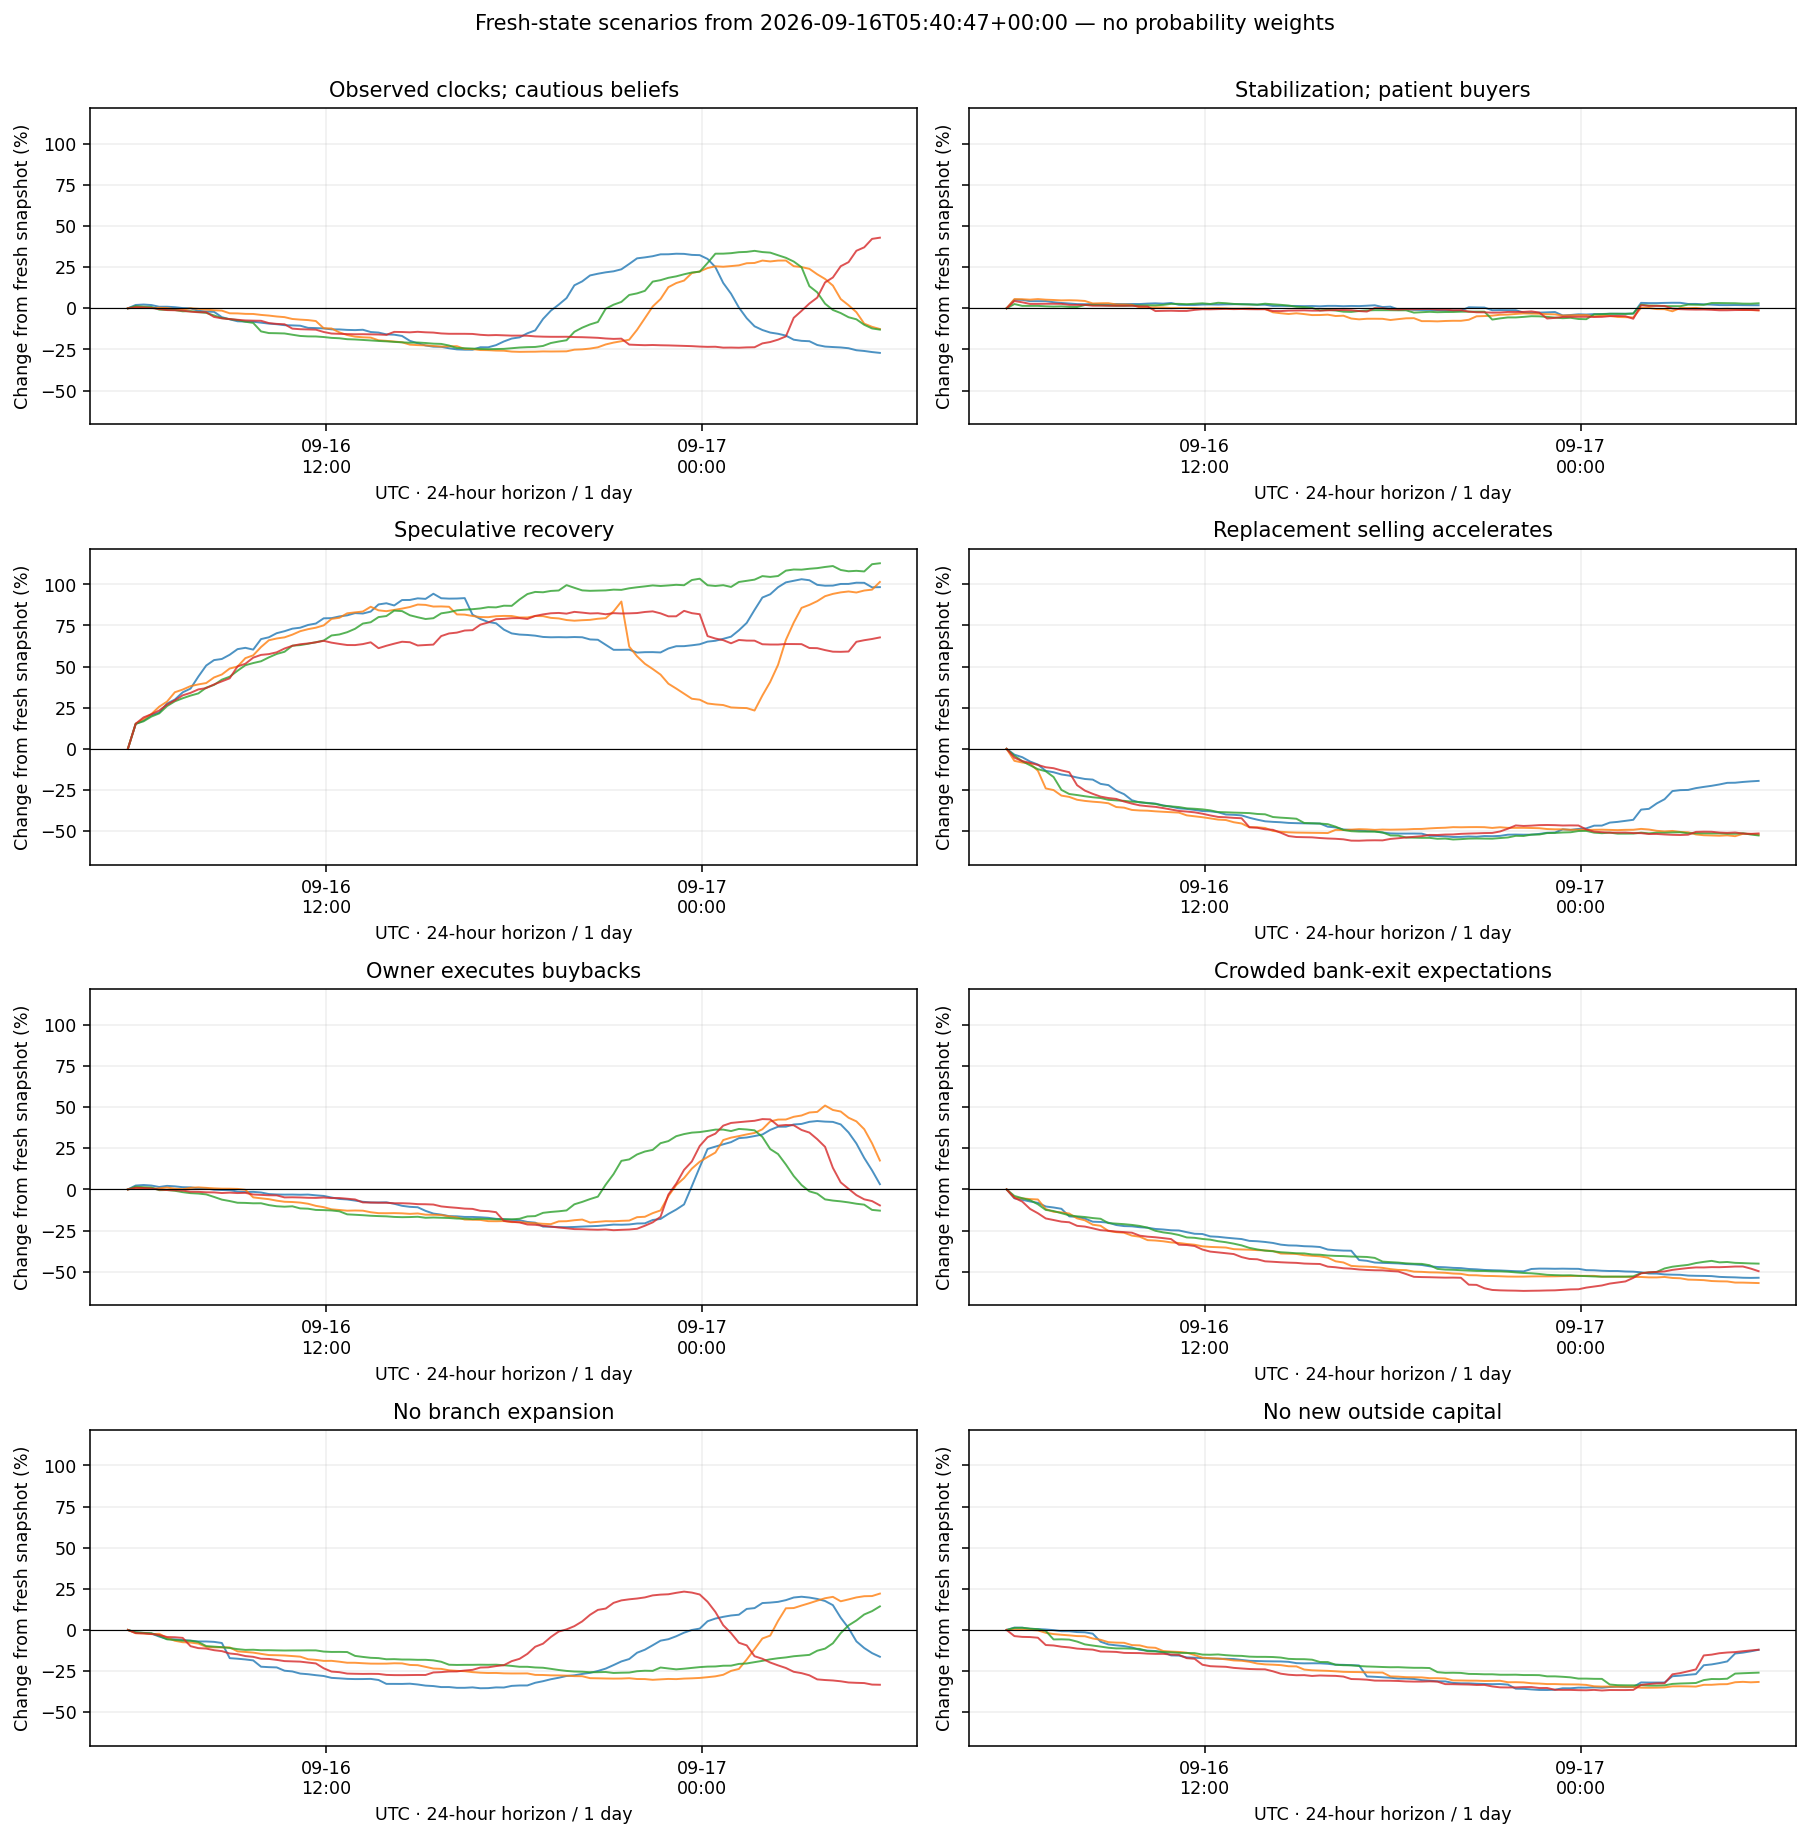

In [5]:
runs=pd.read_csv(D/'scenario-runs.csv')
display(runs.groupby('case',sort=False).agg(median_return=('ending_price_return','median'),minimum=('ending_price_return','min'),maximum=('ending_price_return','max'),licenses=('licenses','median'),fresh_license_ETH=('license_fresh_ETH','median'),prefunding_ETH=('game_prefund_ETH','median')))
display(Image(filename=str(D/'updated-paths.png')))

## 4. Buying budgets and a new buyback trade

No buyback has executed. The isolated trade below assumes successful hourly owner execution with no sellers. The hook balance is not treated as immediately spendable vault ETH.

In [6]:
display(pd.read_csv(D/'buyback-only-trade.csv'))
display(pd.read_csv(D/'recovery-flow-requirements.csv').pivot(index='fraction_recent_seller_stock_sold',columns='target_spot_return',values='required_gross_buyer_ETH'))

,hours,elapsed_days,timestamp_utc,buyback_ETH,spot_change,one_ETH_entry_net_return
0,1,0.041667,2026-09-16T06:40:47+00:00,6.488534,0.003770,-0.065272
1,6,0.250000,2026-09-16T11:40:47+00:00,39.090339,0.020269,-0.049911
2,12,0.500000,2026-09-16T17:40:47+00:00,72.672295,0.037405,-0.033955
3,24,1.000000,2026-09-17T05:40:47+00:00,100.691053,0.051805,-0.020547


target_spot_return,0.00,0.10,0.25,0.50,1.00
fraction_recent_seller_stock_sold,,,,,
0.00,0.000000,187.195788,430.192999,806.672923,1479.305869
0.25,111.964231,299.160019,542.157230,918.637154,1591.270100
0.50,217.772522,404.968310,647.965521,1024.445445,1697.078391
1.00,412.831309,600.027097,843.024307,1219.504232,1892.137178


## 5. Accounting checks

These verify consistency, not forecasting accuracy. Motives, future capital and optimal selling times remain uncertain. The previous method and sensitivity limitations still apply.

In [7]:
errors=pd.read_csv(D/'accounting.csv.gz')
display(errors[['ETH_error','token_error','ledger_error']].abs().max().to_frame('Maximum absolute error'))
assert errors.ETH_error.abs().max()<1e-5
assert errors.token_error.abs().max()<.03
assert errors.ledger_error.abs().max()<1e-5
assert abs(s['fixed_group_bridge_error'])<1e-5
assert len(runs)==32
assert s['remaining_licenses']==0
assert abs(funding['ledger_reconciliation_error_tokens'])<1e-5
print('Saved-state and simulation checks passed.')

,Maximum absolute error
ETH_error,1.073204e-10
token_error,7.673807e-07
ledger_error,1.257285e-08


Saved-state and simulation checks passed.
